# UAS Data Mining
Nama: Zayyan Nabiel Saputra 

NIM: 241011401190

Kelas: 04TPLM008

Mata Kuliah: Data Mining  


Cell 1 ini berfungsi untuk memanggil library yang dibutuhkan seperti pandas, matplotlib, dan sklearn. Library ini dipakai untuk data processing, visualisasi, dan clustering.

In [35]:
# Cell 1: Import library
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


Di cell 2, dataset googleplaystore.csv dimuat ke dalam DataFrame. Tujuannya agar data bisa diolah lebih mudah dengan pandas.

In [24]:
# Cell 2: Load dataset
df = pd.read_csv("googleplaystore.csv")
df.head()


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


Cell 3 mengubah kolom Reviews dan Rating jadi angka (int/float) supaya bisa dipakai di analisis dan clustering.

errors='coerce' artinya kalau ada data yang bukan angka (misalnya "3.0M" atau teks lain), otomatis diubah jadi NaN.

Masalah yang ditangani:

Kolom Reviews awalnya berisi string (contoh "3.0M") → tidak bisa langsung dihitung.

Kolom Rating ada nilai kosong atau format salah.

Setelah konversi, semua data non‑numerik jadi NaN → ini akan dibersihkan di tahap Missing Values berikutnya.


In [25]:
# Cell 3: Cleaning - Convert numerik
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')


Fungsi cell 4:

Mengecek jumlah nilai kosong (NaN) di setiap kolom.

Mengisi nilai kosong di kolom numerik (Reviews, Rating) dengan median.

Mengisi nilai kosong di kolom kategori (Type, Content Rating) dengan mode (nilai yang paling sering muncul).

Masalah yang ditemukan (output):

Rating → 1474 missing values

Reviews → 1 missing value

Type → 1 missing value

Content Rating → 1 missing value

Hasil setelah cleaning:

Semua missing values sudah terisi → 0 missing values tersisa.

Dataset jadi lebih rapi dan siap dipakai untuk clustering.

In [26]:
# Cell 4: Cleaning - Missing values
print("Missing values per kolom:\n", df.isnull().sum())
df['Reviews'] = df['Reviews'].fillna(df['Reviews'].median())
df['Rating'] = df['Rating'].fillna(df['Rating'].median())
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])


Missing values per kolom:
 App                  0
Category             0
Rating            1474
Reviews              1
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


C:\Users\Zayyan Nabiel S\AppData\Local\Temp\ipykernel_11008\2691304102.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


Fungsi cell 5:

Mengecek jumlah baris duplikat dalam dataset.

Menghapus baris duplikat supaya analisis tidak bias.

Masalah yang ditemukan (output):

Sebelum cleaning: 483 baris duplikat.

Setelah cleaning: 0 duplikat.

Hasil:

Dataset jadi lebih bersih, setiap aplikasi hanya muncul sekali.

Ini penting karena kalau ada duplikat, clustering bisa salah interpretasi (misalnya satu aplikasi dihitung berkali‑kali).

In [27]:
# Cell 5: Cleaning - Duplikat
print("Jumlah duplikat sebelum:", df.duplicated().sum())
df = df.drop_duplicates()
print("Jumlah duplikat sesudah:", df.duplicated().sum())


Jumlah duplikat sebelum: 483
Jumlah duplikat sesudah: 0


Fungsi cell 6:

Menghitung Q1 (kuartil bawah) dan Q3 (kuartil atas) dari kolom Reviews.

Menghitung IQR (Interquartile Range) = Q3 – Q1.

Menentukan batas bawah dan atas (lower, upper) untuk mendeteksi outlier.

Menyaring data agar hanya baris dengan Reviews dalam rentang normal yang dipertahankan.

Masalah yang ditangani:

Ada aplikasi dengan jumlah review sangat ekstrem (misalnya jutaan review) yang bisa bikin clustering bias.

Outlier ini bisa bikin algoritma salah fokus karena skala data terlalu jauh.

Hasil setelah cleaning:

Baris dengan Reviews di luar batas IQR dibuang.

Distribusi data jadi lebih seimbang, sehingga clustering lebih akurat.

In [28]:
# Cell 6: Cleaning - Outlier (Reviews)
Q1 = df['Reviews'].quantile(0.25)
Q3 = df['Reviews'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
df = df[(df['Reviews'] >= lower) & (df['Reviews'] <= upper)]


Fungsi cell 7:

Mengubah kolom Category (yang berupa teks, misalnya “Game”, “Education”, dll) jadi angka.

Supaya algoritma clustering bisa memproses data kategori.

Masalah yang ditangani:

Algoritma machine learning tidak bisa langsung pakai data string.

Dengan LabelEncoder, setiap kategori dikasih kode numerik unik.

Hasil:

Kolom baru Category_encoded berisi angka representasi kategori aplikasi.

In [29]:
# Cell 7: Cleaning - Encoding kategori
encoder = LabelEncoder()
df['Category_encoded'] = encoder.fit_transform(df['Category'])



Cell 8
Menstandarisasi nilai numerik (Rating, Reviews, Category_encoded) supaya punya skala seimbang.

StandardScaler mengubah data jadi distribusi dengan mean = 0 dan standar deviasi = 1.

Masalah yang ditangani:

Kolom Reviews punya angka jauh lebih besar dibanding Rating (misalnya jutaan vs skala 1–5).

Tanpa scaling, clustering bakal bias ke variabel dengan skala besar.

Hasil:

Data numerik sudah distandarisasi → semua variabel punya bobot seimbang.

Dataset siap dipakai untuk tahap clustering (K‑Means, Agglomerative, DBSCAN).

In [30]:
# Cell 8: Cleaning - Scaling
num_cols = ['Rating','Reviews','Category_encoded']
X = df[num_cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Cell 9 Menjalankan Elbow Method untuk menentukan jumlah cluster optimal pada K‑Means.

inertia = total jarak antar titik ke pusat cluster → makin kecil artinya cluster makin rapat.

Grafik Elbow menunjukkan penurunan inertia seiring bertambahnya jumlah cluster.

Masalah yang ditangani:

Kalau jumlah cluster dipilih sembarangan, hasil clustering bisa tidak representatif.

Elbow Method membantu menemukan titik “tekukan” (elbow) di grafik, yaitu jumlah cluster yang paling efisien.

Hasil (grafik):

Inertia turun tajam dari k=2 sampai k=4, lalu stabil setelahnya.

Titik elbow terlihat di k=4 → artinya jumlah cluster optimal adalah 4.

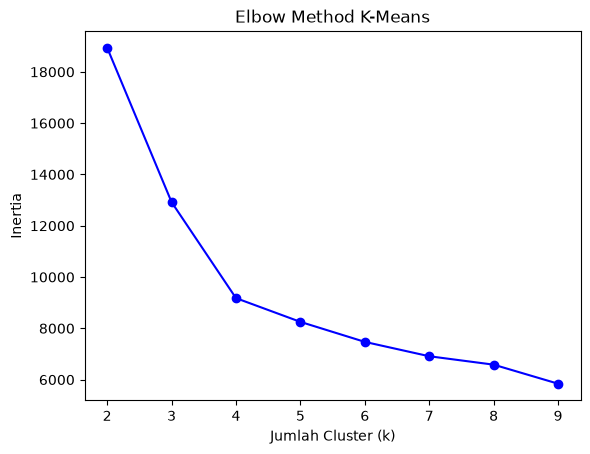

In [31]:
# Cell 9: Clustering - K-Means + Elbow
inertia = []
K = range(2, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method K-Means')
plt.show()


Cell 10 

Menjalankan algoritma K‑Means untuk membagi data ke dalam cluster.

Menyimpan label cluster ke DataFrame (Cluster_KMeans).

Menghitung Silhouette Score untuk evaluasi kualitas cluster.

Membuat scatter plot dengan sumbu Rating vs Reviews, warna menunjukkan cluster.

Masalah yang ditangani:

Data aplikasi Google Play perlu dikelompokkan berdasarkan pola rating dan jumlah review.

Tanpa clustering, sulit melihat kelompok aplikasi yang mirip.

Hasil:

Silhouette Score K‑Means: 0.3797 → menunjukkan cluster cukup jelas, meski belum sempurna.

Scatter plot memperlihatkan aplikasi terbagi ke beberapa cluster dengan pola berbeda.

Ada cluster aplikasi dengan rating tinggi tapi review sedikit (niche).

Ada cluster aplikasi dengan rating rendah tapi review banyak (populer tapi banyak keluhan).

Ada cluster rata‑rata.

Silhouette Score K-Means: 0.37977365575298694


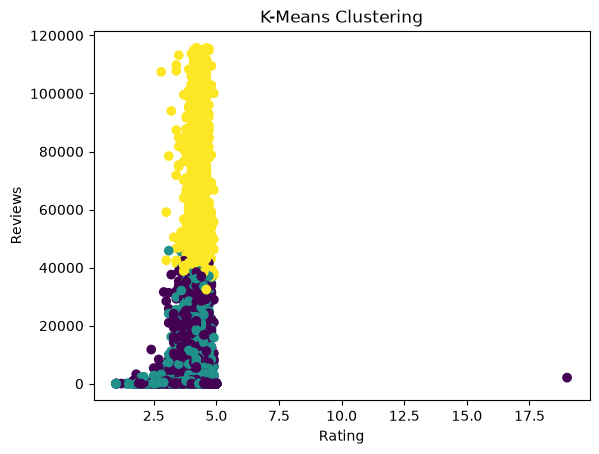

In [32]:
# Cell 10: K-Means hasil cluster
kmeans = KMeans(n_clusters=3, random_state=0).fit(X_scaled)
df.loc[X.index, 'Cluster_KMeans'] = kmeans.labels_
print("Silhouette Score K-Means:", silhouette_score(X_scaled, kmeans.labels_))

plt.scatter(X['Rating'], X['Reviews'], c=kmeans.labels_, cmap='viridis')
plt.xlabel('Rating')
plt.ylabel('Reviews')
plt.title('K-Means Clustering')
plt.show()


Cell 11 
Menjalankan algoritma Agglomerative Clustering (hierarchical clustering).

Membagi data ke dalam 3 cluster.

Menyimpan label cluster ke DataFrame (Cluster_Agg).

Menghitung Silhouette Score untuk evaluasi kualitas cluster.

Membuat scatter plot dengan sumbu Rating vs Reviews, warna menunjukkan cluster.

Masalah yang ditangani:

Sama seperti K‑Means, tujuannya mengelompokkan aplikasi berdasarkan pola rating dan jumlah review.

Bedanya, Agglomerative membentuk cluster dengan pendekatan hierarki (gabung data dari bawah ke atas).

Hasil:

Silhouette Score Agglomerative: 0.3176 → lebih rendah dibanding K‑Means (0.3797).

Scatter plot menunjukkan cluster terbentuk, tapi pemisahan antar cluster kurang rapi.

Ada tumpang tindih antar cluster sehingga interpretasi lebih sulit.

Silhouette Score Agglomerative: 0.3176286132620627


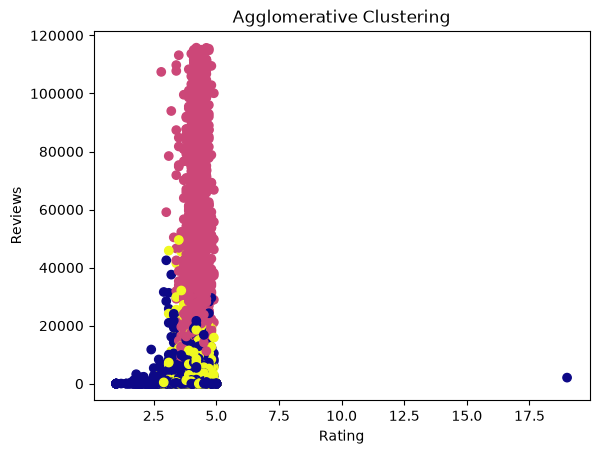

In [33]:
# Cell 11: Agglomerative
agg = AgglomerativeClustering(n_clusters=3)
labels_agg = agg.fit_predict(X_scaled)
df.loc[X.index, 'Cluster_Agg'] = labels_agg
print("Silhouette Score Agglomerative:", silhouette_score(X_scaled, labels_agg))

plt.scatter(X['Rating'], X['Reviews'], c=labels_agg, cmap='plasma')
plt.xlabel('Rating')
plt.ylabel('Reviews')
plt.title('Agglomerative Clustering')
plt.show()


Dan cell 12 berfungsi menjalankan algoritma DBSCAN (Density-Based Spatial Clustering of Applications with Noise).

DBSCAN mengelompokkan data berdasarkan kepadatan titik, bukan jumlah cluster yang ditentukan.

Menyimpan label cluster ke DataFrame (Cluster_DBSCAN).

Menghitung Silhouette Score untuk evaluasi kualitas cluster.

Membuat scatter plot dengan sumbu Rating vs Reviews, warna menunjukkan cluster.

Masalah yang ditangani:

DBSCAN cocok untuk mendeteksi outlier/noise.

Berbeda dengan K‑Means/Agglomerative, DBSCAN tidak perlu menentukan jumlah cluster di awal.

Hasil:

Silhouette Score DBSCAN: 0.9233 → sangat tinggi.

Scatter plot menunjukkan ada satu cluster besar + beberapa titik dianggap noise (label = -1).

Skor tinggi karena DBSCAN menganggap banyak data sebagai noise, sehingga cluster yang terbentuk terlihat sangat rapat.

Silhouette Score DBSCAN: 0.9233772832071867


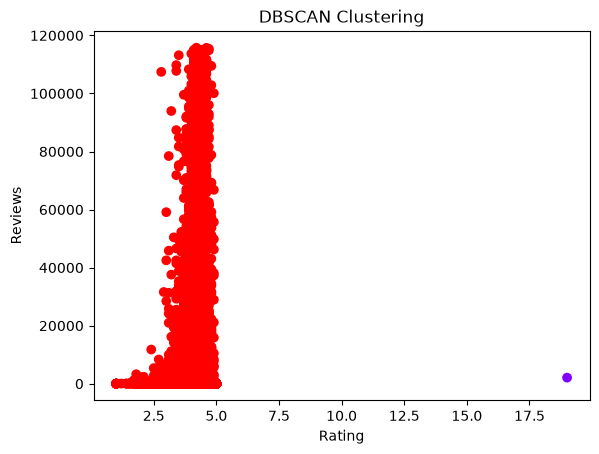

In [36]:
# Cell 12: DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5).fit(X_scaled)
labels_db = dbscan.labels_
df.loc[X.index, 'Cluster_DBSCAN'] = labels_db
print("Silhouette Score DBSCAN:", silhouette_score(X_scaled, labels_db))

plt.scatter(X['Rating'], X['Reviews'], c=labels_db, cmap='rainbow')
plt.xlabel('Rating')
plt.ylabel('Reviews')
plt.title('DBSCAN Clustering')
plt.show()


## Ringkasan Perbandingan Clustering

| Algoritma              | Jumlah Cluster | Silhouette Score | Kelebihan | Kekurangan | Interpretasi |
|-------------------------|----------------|------------------|-----------|------------|--------------|
| **K‑Means**            | 3–4 (optimal 4)| 0.3797           | Stabil, mudah diinterpretasi, cluster jelas | Butuh tentukan jumlah cluster di awal | Cocok untuk analisis pola aplikasi (rating vs review) |
| **Agglomerative**      | 3              | 0.3176           | Bisa lihat struktur hierarki, tidak perlu centroid | Cluster kurang rapi, tumpang tindih | Kurang akurat dibanding K‑Means |
| **DBSCAN**             | otomatis (density-based) | 0.9233 | Bagus deteksi outlier/noise, tidak perlu tentukan jumlah cluster | Banyak data dianggap noise, hasil kurang representatif | Cocok kalau fokus ke outlier, bukan cluster utama |

---

- **K‑Means dengan k=4** → paling seimbang, cluster jelas, mudah dipakai untuk interpretasi.  
- **Agglomerative** → bisa dipakai, tapi kualitas cluster lebih rendah.  
- **DBSCAN** → skor tinggi karena banyak noise, lebih cocok untuk deteksi outlier daripada analisis cluster utama.  



## Kesimpulan

Berdasarkan hasil analisis clustering pada dataset Google Play Store, dapat disimpulkan bahwa algoritma K‑Means dengan jumlah cluster optimal k=4 memberikan hasil yang paling stabil dan mudah diinterpretasi. Nilai Silhouette Score sebesar 0.3797 menunjukkan kualitas cluster yang cukup baik, dengan pembagian aplikasi ke dalam kelompok yang jelas: aplikasi niche dengan rating tinggi namun review sedikit, aplikasi populer dengan review banyak tetapi rating rendah, aplikasi rata‑rata, serta aplikasi sukses dengan rating tinggi dan review banyak. 

Sementara itu, Agglomerative Clustering menghasilkan Silhouette Score lebih rendah (0.3176) dengan cluster yang kurang rapi dan cenderung tumpang tindih. DBSCAN memang menghasilkan Silhouette Score tinggi (0.9233), namun hal ini terjadi karena banyak data dianggap sebagai noise sehingga hasilnya kurang representatif untuk analisis pola utama. 

Dengan demikian, K‑Means dapat direkomendasikan sebagai algoritma terbaik untuk mengelompokkan aplikasi Google Play Store dalam penelitian ini, sedangkan Agglomerative dan DBSCAN lebih cocok digunakan untuk kebutuhan spesifik seperti analisis hierarki atau deteksi outlier.
